# To show the 800 outputs of the standard N2V and the constrained N2V 

We used a simulated galaxy.

In [1]:
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
import torch
from matplotlib import pyplot as plt
import os

In [2]:
path = '../data saved/'

stamps_ori = np.load(path + 'stampcor_bright.npy')
stamps_cle = np.load(path + 'stampcle_bright.npy')

In [3]:
os.chdir('../pn2v/src/pn2v')
from core import utils
from unet import UNet
from core import prediction
device = utils.getDevice()

os.chdir('../../..')
os.chdir('./model saved')

net=torch.load("N2V_simulation.net", weights_only=False)
net2=torch.load("constrained_N2V_simulation.net", weights_only=False)

CUDA available? True


In [4]:
num = 80
n2vResult_800 = prediction.predict_Jiefeng(stamps_ori[num], net ,device=device,noiseModel=None)
n2vResult = prediction.tiledPredict(stamps_ori[num], net ,ps=96, overlap=48,
                                            device=device, noiseModel=None)
n2vResult_8002 = prediction.predict_Jiefeng(stamps_ori[num], net2 ,device=device,noiseModel=None)

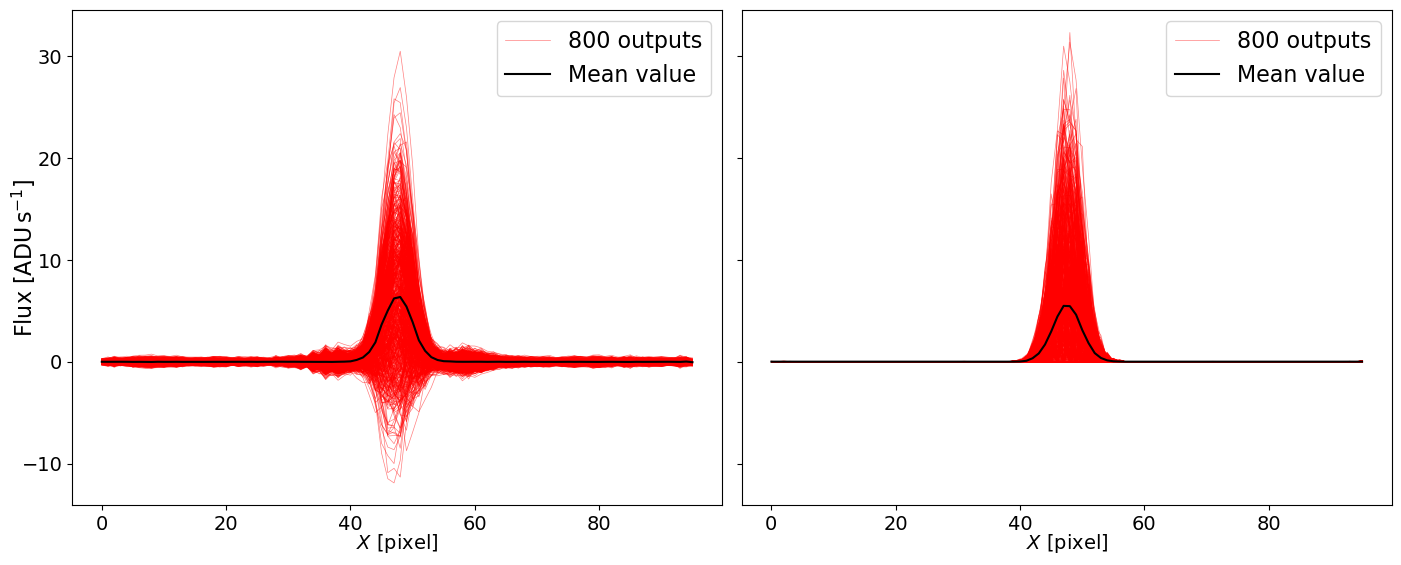

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i in range(len(n2vResult_8002[0])):
    label_text = '800 outputs' if i == 0 else "_nolegend_"
    ax1.plot(n2vResult_8002[0][i][48], c='red', alpha=0.5, linewidth=0.5, label=label_text)

ax1.plot(n2vResult_8002[1][48], c='black', linewidth=1.5, label='Mean value')
ax1.legend(loc='upper right',fontsize=16)

ax1.set_ylabel(r'Flux $[\mathrm{ADU}\,\mathrm{s}^{-1}]$', fontsize=16, labelpad=-12)
ax1.set_xlabel(r'$X$ $[\mathrm{pixel}]$', fontsize=14, rotation=0, y=-2, va='bottom', labelpad=15)


for i in range(len(n2vResult_800[0])):
    label_text = '800 outputs' if i == 0 else "_nolegend_"
    ax2.plot(n2vResult_800[0][i][48], c='red', alpha=0.5, linewidth=0.5, label=label_text)

ax2.plot(n2vResult[48], c='black', linewidth=1.5, label='Mean value')
ax2.legend(loc='upper right',fontsize=16)
ax2.set_xlabel(r'$X$ $[\mathrm{pixel}]$', fontsize=14, rotation=0, y=-2, va='bottom', labelpad=15)

plt.subplots_adjust(wspace=0.1) 


plt.tight_layout(rect=[0, 0.05, 1, 1])
ax1.tick_params(labelsize=14)  
ax2.tick_params(labelsize=14)

plt.show()